 import xgboost as xgb   
 
 # XGBoost：
  一棵一棵種
  第一棵樹先預測
  第二棵樹專門修正第一棵的錯誤
  第三棵樹修正前兩棵的錯誤
  ...
  每棵樹都在改善前一棵的缺點
    這個概念叫做 Boosting（提升）。

# 優點：
  → 競賽最常拿獎的模型
  → Boosting 讓每棵樹互相補強
  → Early Stopping 自動防止過擬合
  → 可以看特徵重要性
  → 速度比 Random Forest 快

# 缺點：
  → 參數多，需要調整
  → 對異常值敏感
  → 需要比較多時間調參

# 重要參數：
  n_estimators   → 最多幾棵樹
  learning_rate  → 每步修正多少
  max_depth      → 每棵樹深度
  early_stopping → 自動停止

# 語法
  model_es.fit(
    X_train,                  # 訓練特徵
    y_train,                  # 訓練標籤
    eval_set=[                # 驗證集
        (X_test, y_test)      # 驗證特徵、驗證標籤
    ],
    verbose=50                # 每50輪印一次訓練資訊
)

model      # 一般模型
model_es   # Early Stopping模型
(.fit 前名子可自取)

# 繪製特徵重要性圖
xgb.plot_importance(
    model_es,          # 已訓練完成的 XGBoost 模型
    max_num_features=10 # 只顯示前10個最重要特徵
)

# 設定圖表標題
plt.title('XGBoost 特徵重要性')

# 顯示圖表
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X,y=make_classification(n_samples=1000,n_features=20,n_classes=2,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model = xgb.XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)

model.fit(X_train, y_train)
y_pred=model.predict(X_test)

print("test_Accuracy:", accuracy_score(y_test, y_pred))
print("train_Accuracy:", accuracy_score(y_train, model.predict(X_train)))

test_Accuracy: 0.895
train_Accuracy: 0.9875


In [7]:
model_es = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    random_state=42,
    early_stopping_rounds=20
)

model_es.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\n最佳樹的數量: {model_es.best_iteration}")
print(f"測試準確率: {accuracy_score(y_test, model_es.predict(X_test)):.4f}")

[0]	validation_0-logloss:0.68875
[50]	validation_0-logloss:0.49591
[100]	validation_0-logloss:0.40279
[150]	validation_0-logloss:0.35433
[200]	validation_0-logloss:0.33049
[250]	validation_0-logloss:0.31688
[300]	validation_0-logloss:0.30428
[350]	validation_0-logloss:0.29923
[400]	validation_0-logloss:0.29746
[427]	validation_0-logloss:0.29780

最佳樹的數量: 407
測試準確率: 0.9000


c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24501 (\N{CJK UNIFIED IDEOGRAPH-5FB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\light\competition\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAP

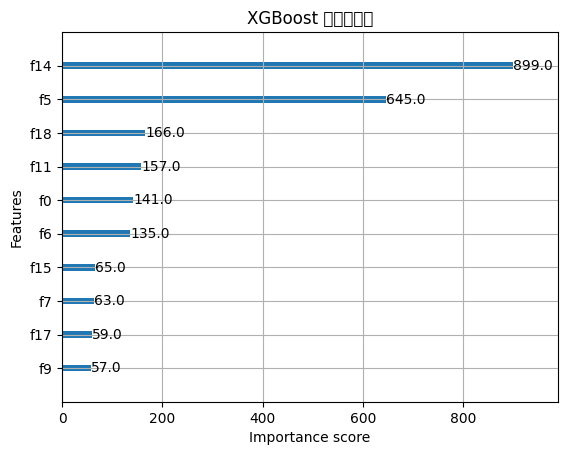

In [8]:
xgb.plot_importance(model_es, max_num_features=10)
plt.title('XGBoost 特徵重要性')
plt.show()